# **Atividade de PDI - Processamento Digital de Imagens**

---

#### **Questão 1. Recortes e Mesclas com Matrizes (Fatiamento)**

##### **a) Criando a Máscara:**

In [ ]:
%pip install numpy matplotlib

In [148]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

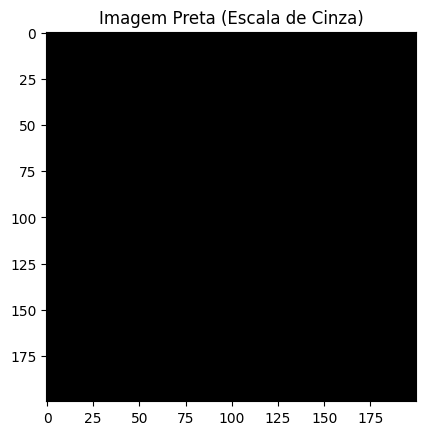

In [149]:
# imagem 200x200, pixels pretos (0)
imagem_preta = np.ones((200, 200), dtype=np.uint8) * 0

plt.imshow(imagem_preta, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem Preta (Escala de Cinza)')
plt.show()

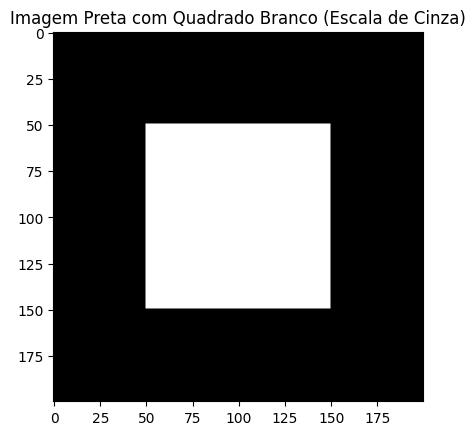

In [150]:
imagem_preta[50:150, 50:150] = 255

plt.imshow(imagem_preta, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem Preta com Quadrado Branco (Escala de Cinza)')
plt.show()

##### **b) Criando o degradê**

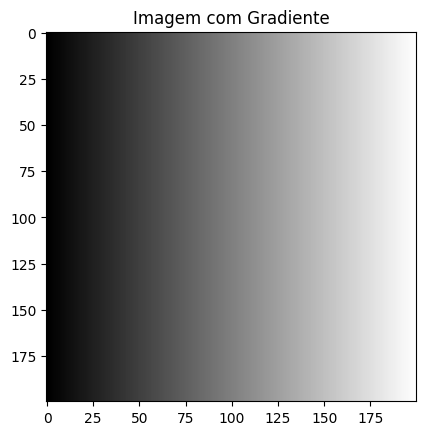

In [151]:
# imagem 200x200
imagem_degrade = np.zeros((200, 200), dtype=np.uint8)

# gradiente horizontal
imagem_degrade = np.linspace(0, 255, 200, dtype=np.uint8).reshape(1,  200) 

# repete o gradiente para preencher a imagem
imagem_degrade = np.repeat(imagem_degrade, 200, axis=0)

plt.imshow(imagem_degrade, cmap='gray')
plt.title('Imagem com Gradiente')
plt.show()


##### **c) Mesclando as imagens**

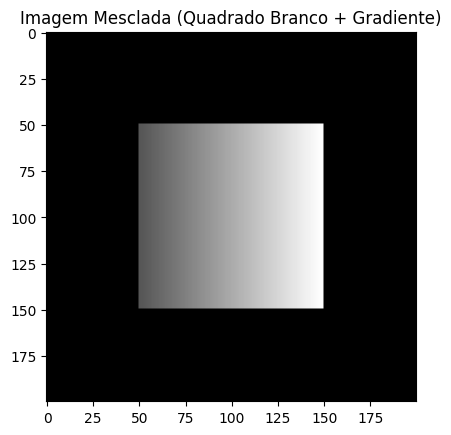

In [152]:
# se imagem_preta for 0, mantém imagem_preta. senão, usa o valor de imagem_degrade
imagem_mesclada = np.where(imagem_preta == 0, imagem_preta, imagem_degrade)

plt.imshow(imagem_mesclada, cmap='gray')
plt.title('Imagem Mesclada (Quadrado Branco + Gradiente)')
plt.show()

#### **Questão 2. Brincando com Canais de Cor (Espaço RGB)**

##### **a) Importando imagem**

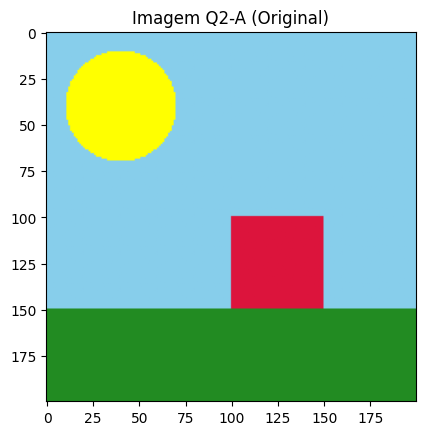

In [153]:
img_q2_a = plt.imread('q2_a_original.png', format='png')

plt.imshow(img_q2_a, cmap='gray')
plt.title('Imagem Q2-A (Original)')
plt.show()

##### **b) Efeito Inverso (Troca de Canais - Formato BGR)**

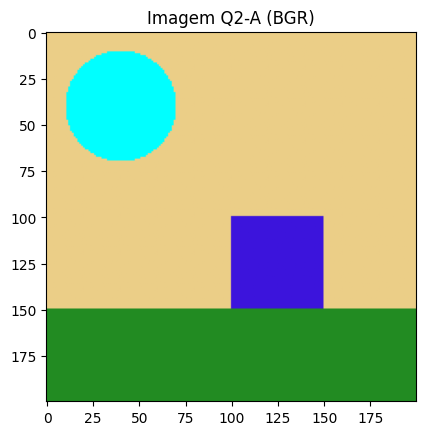

In [154]:
# convertendo de RGB para BGR
img_q2_a_BGR = img_q2_a[:, :, [2,1,0]]

plt.imshow(img_q2_a_BGR)
plt.title('Imagem Q2-A (BGR)')
plt.show()

##### **c) Filtro Vermelho Forte**

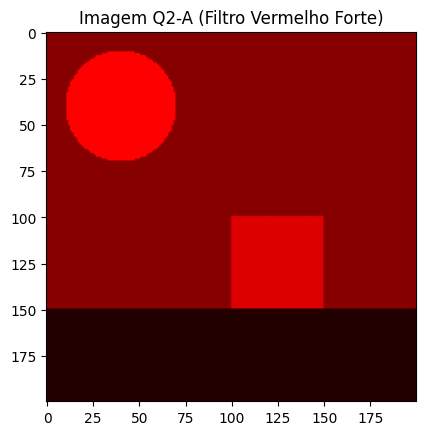

In [155]:
img_q2_a_red = img_q2_a.copy()

img_q2_a_red[..., 1] = 0  # canal verde
img_q2_a_red[..., 2] = 0  # canal azul

plt.imshow(img_q2_a_red)
plt.title('Imagem Q2-A (Filtro Vermelho Forte)')
plt.show()

#### **3. Calculos Estatísticos e Limiarização**

##### **a) Conversão para Tons de Cinza pela Média:**

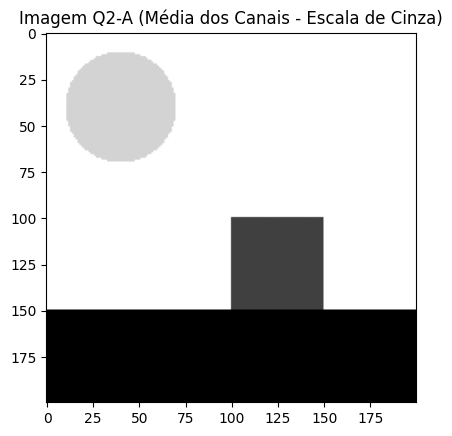

In [156]:
# convertendo para escala de cinza usando a média dos canais
img_cinza = (np.mean(img_q2_a, axis=2) * 255).astype(np.uint8)

plt.imshow(img_cinza, cmap='gray')
plt.title('Imagem Q2-A (Média dos Canais - Escala de Cinza)')
plt.show()

##### **b) Histograma e a Média Geral**

Média geral dos pixels: 178.5639


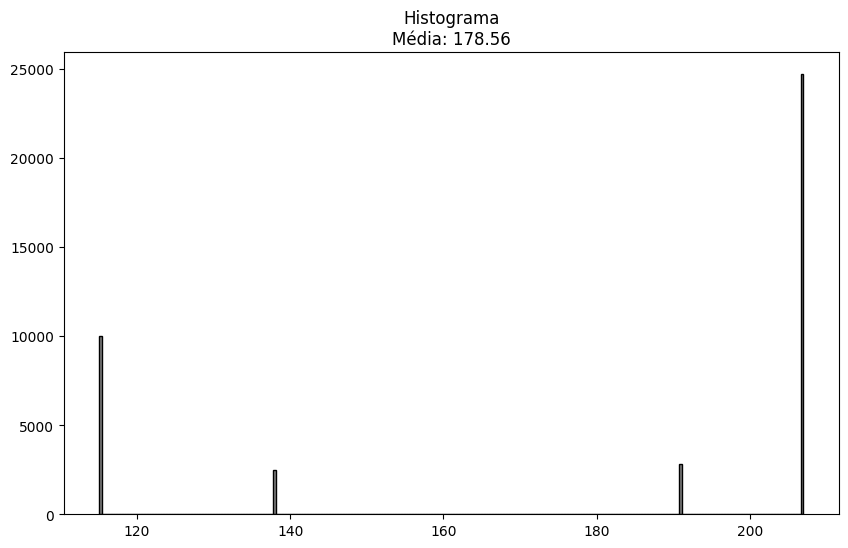

In [157]:
# cálculo da média geral de todos os pixels
media_geral = np.mean(img_cinza)
print(f'Média geral dos pixels: {media_geral}')

# histograma com 255 bins
plt.figure(figsize=(10, 6))
plt.hist(img_cinza.flatten(), bins=255, color='gray', edgecolor='black')
plt.title(f'Histograma\nMédia: {media_geral:.2f}')
plt.show()

##### **c) Limiarização Analítica Automática**

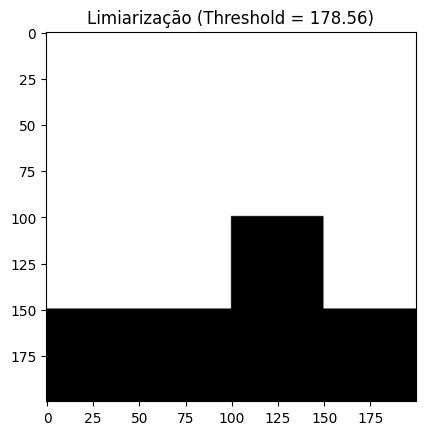

In [158]:
# usando a média como limiar
threshold = media_geral

# criando a imagem binária (máscara)
img_limiarizada = np.where(img_cinza >= threshold, 255, 0).astype(np.uint8)

# exibindo resultado
plt.imshow(img_limiarizada, cmap='gray')
plt.title(f'Limiarização (Threshold = {threshold:.2f})')
plt.show()

#### **4. Efeito ”Chroma Key” (Isolando a Máscara e Substituindo o Fundo)**

##### **a) Isolando/Mapeando o Fundo**

In [159]:
print(img_q2_a[10, 10])  # pega um ponto do céu

[0.5294118  0.80784315 0.92156863 1.        ]


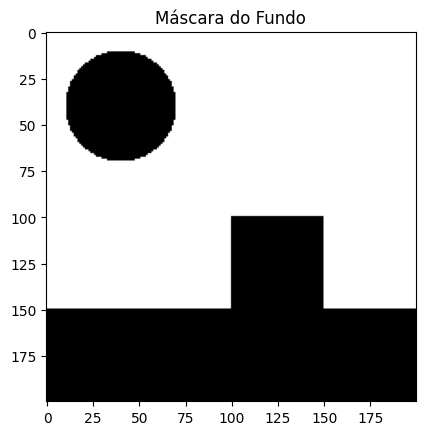

In [160]:
# valores de R, G, B do céu (normalizados entre 0 e 1)
R_ref = 0.5294118
G_ref = 0.80784315
B_ref = 0.92156863

# criando máscara booleana do fundo
mascara_fundo = (
    (np.abs(img_q2_a[:, :, 0] - R_ref) <= 0.05) &
    (np.abs(img_q2_a[:, :, 1] - G_ref) <= 0.05) &
    (np.abs(img_q2_a[:, :, 2] - B_ref) <= 0.05)
)

plt.imshow(mascara_fundo, cmap='gray')
plt.title('Máscara do Fundo')
plt.show()

##### **b) Gerando ou Recebendo um Novo Fundo**

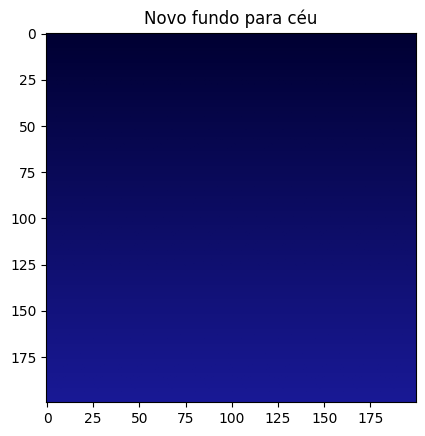

In [161]:
novo_fundo = plt.imread('q4_b_fundo.png', format='png')

plt.imshow(novo_fundo, cmap='gray')
plt.title('Novo fundo para céu')
plt.show()

##### **c) Sobreposição e Mescla (verdadeiro Chroma Key)**

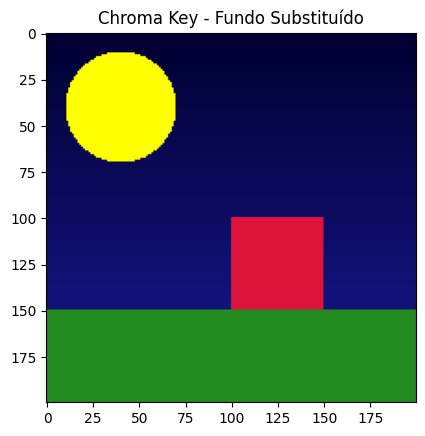

In [163]:
# garantir que o fundo novo tem o mesmo tamanho
novo_fundo = novo_fundo[:, :, :3]
img_original = img_q2_a[:, :, :3]

# cópia da imagem original
imagem_final = img_original.copy()

# aplicação do chroma key
imagem_final[mascara_fundo] = novo_fundo[mascara_fundo]

# exibir resultado
plt.imshow(imagem_final)
plt.title('Chroma Key - Fundo Substituído')
plt.show()